In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('Water_pond_tanks_2021.csv' , encoding='latin1')

print("Total rows :", len(df))
print("Total columns:", len(df.columns))
print()
print("First five rows of the data")
df.head()


Total rows : 620
Total columns: 20

First five rows of the data


,STN\nCode,Name of Monitoring Location,Type Water Body,State Name,Temperature\n?C (Min),Temperature\n?C (Max),Dissolved Oxygen (mg/L) (Min),Dissolved Oxygen (mg/L) (Max),pH (Min),pH (Max),Conductivity (?mhos/cm) (Min),Conductivity (?mhos/cm) (Max),BOD (mg/L) (Min),BOD (mg/L) (Max),Nitrate N + Nitrite N(mg/L) (Min),Nitrate N + Nitrite N(mg/L) (Max),Fecal Coliform (MPN/100ml) (Min),Fecal Coliform (MPN/100ml) (Max),Total Coliform (MPN/100ml) (Min),Total Coliform (MPN/100ml) (Max)
0,4368.0,"KOLLERU LAKE KOKKIRAYALANKA (V), KAILALUR (M)",LAKE,ANDHRA PRADESH,24.0,27.0,3.2,6.5,7.0,8.0,245,5160,1.6,3.2,1.02,3.60,9,21,120,210
1,2353.0,"KONDAKARLA-AAVA LAKE, PARAWADA PHARMA CITY, VI...",LAKE,ANDHRA PRADESH,26.0,29.0,3.0,6.8,6.9,7.8,599,1179,1.9,4.6,0.77,3.56,15,23,150,240
2,1790.0,"PULICATE LAKE , NELLORE DIST",LAKE,ANDHRA PRADESH,18.0,24.0,4.2,6.0,7.2,8.2,28000,56900,2.4,2.8,1.20,1.64,3,3,47,150
3,4391.0,"CHENGAMBAKAM TANK IN SRI CITY SEZ,\nTIRUPATHI",TANK,ANDHRA PRADESH,22.0,29.0,5.4,6.2,6.3,7.9,180,476,1.0,2.5,0.34,2.30,24,365,170,549
4,4921.0,ANNAMAYYA PROJECT ON CHEYYERU\nRESERVOIR,Wetland,ANDHRA PRADESH,21.0,30.0,5.4,6.5,7.3,8.0,496,734,1.0,2.3,0.35,1.00,43,289,240,727


In [3]:
#See Column Names
print("Current columns name")
for i , col in enumerate(df.columns):
    print(i+1,"->",col)


Current columns name
1 -> STN
Code
2 -> Name of Monitoring Location
3 -> Type Water Body
4 -> State Name
5 -> Temperature
?C (Min)
6 -> Temperature
?C (Max)
7 -> Dissolved Oxygen (mg/L) (Min)
8 -> Dissolved Oxygen (mg/L) (Max)
9 -> pH (Min)
10 -> pH (Max)
11 -> Conductivity (?mhos/cm) (Min)
12 -> Conductivity (?mhos/cm) (Max)
13 -> BOD (mg/L) (Min)
14 -> BOD (mg/L) (Max)
15 -> Nitrate N + Nitrite N(mg/L) (Min)
16 -> Nitrate N + Nitrite N(mg/L) (Max)
17 -> Fecal Coliform (MPN/100ml) (Min)
18 -> Fecal Coliform (MPN/100ml) (Max)
19 -> Total Coliform (MPN/100ml) (Min)
20 -> Total Coliform (MPN/100ml) (Max)


In [4]:


df.columns = [
    'STN_Code',
    'Location_Name',
    'Water_Body_Type',
    'State_Name',
    'Temperature_Min',
    'Temperature_Max',
    'DO_Min',
    'DO_Max',
    'pH_Min',
    'pH_Max',
    'Conductivity_Min',
    'Conductivity_Max',
    'BOD_Min',
    'BOD_Max',
    'Nitrate_Min',
    'Nitrate_Max',
    'Fecal_Coliform_Min',
    'Fecal_Coliform_Max',
    'Total_Coliform_Min',
    'Total_Coliform_Max'
]

print("Columns renamed successfully!")
print()
for i, col in enumerate(df.columns):
    print(i+1, "→", col)

Columns renamed successfully!

1 → STN_Code
2 → Location_Name
3 → Water_Body_Type
4 → State_Name
5 → Temperature_Min
6 → Temperature_Max
7 → DO_Min
8 → DO_Max
9 → pH_Min
10 → pH_Max
11 → Conductivity_Min
12 → Conductivity_Max
13 → BOD_Min
14 → BOD_Max
15 → Nitrate_Min
16 → Nitrate_Max
17 → Fecal_Coliform_Min
18 → Fecal_Coliform_Max
19 → Total_Coliform_Min
20 → Total_Coliform_Max


In [5]:
#Checking Missing Values:
print("Misiing values in each columns:")
print(df.isnull().sum())
print()
print("Total missing values:" , df.isnull().sum().sum())

Misiing values in each columns:
STN_Code              1
Location_Name         0
Water_Body_Type       0
State_Name            0
Temperature_Min       3
Temperature_Max       3
DO_Min                0
DO_Max                0
pH_Min                0
pH_Max                0
Conductivity_Min      2
Conductivity_Max      2
BOD_Min               0
BOD_Max               0
Nitrate_Min           0
Nitrate_Max           0
Fecal_Coliform_Min    1
Fecal_Coliform_Max    1
Total_Coliform_Min    1
Total_Coliform_Max    1
dtype: int64

Total missing values: 15


In [6]:
# Fix state names
df['State_Name'] = (df['State_Name']
                    .str.replace('\n', ' ')
                    .str.strip()
                    .str.upper())

print("States fixed!")
print(df['State_Name'].value_counts())

States fixed!
State_Name
KARNATAKA           165
TELANGANA           125
ASSAM                45
MADHYA PRADESH       35
JAMMU & KASHMIR      30
ANDHRA PRADESH       25
GUJARAT              21
RAJASTHAN            20
KERALA               18
MANIPUR              18
TRIPURA              18
ODISHA               15
WEST BENGAL          13
GOA                   9
TAMIL NADU            9
MEGHALAYA             7
JHARKHAND             6
BIHAR                 5
HIMACHAL PRADESH      5
HARYANA               4
MIZORAM               4
UTTAR PRADESH         4
DELHI                 3
LAKSHADWEEP           3
PUDUCHERRY            3
PUNJAB                3
CHHATTISGARH          2
NAGALAND              2
UTTARAKHAND           2
CHANDIGARH            1
Name: count, dtype: int64


In [7]:
# Convert these columns from text to numbers
cols_to_convert = [
    'DO_Min', 'DO_Max',
    'pH_Min', 'pH_Max',
    'Conductivity_Min', 'Conductivity_Max',
    'BOD_Min', 'BOD_Max',
    'Nitrate_Min', 'Nitrate_Max',
    'Fecal_Coliform_Min', 'Fecal_Coliform_Max',
    'Total_Coliform_Min', 'Total_Coliform_Max',
    'Temperature_Min', 'Temperature_Max'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion done!")


Conversion done!


In [8]:
#Filling Missing Values:
# After converting text to numbers some cells became NaN (empty):
#filling them with the median value of that column


for col in df.select_dtypes(include='number').columns:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

print("Missing values after filling:")
print(df.isnull().sum())
print()
print("No more missing values!")


Missing values after filling:
STN_Code               1
Location_Name          0
Water_Body_Type        0
State_Name             0
Temperature_Min        3
Temperature_Max        3
DO_Min                 2
DO_Max                 2
pH_Min                 1
pH_Max                 0
Conductivity_Min       5
Conductivity_Max       5
BOD_Min                2
BOD_Max                2
Nitrate_Min           52
Nitrate_Max           52
Fecal_Coliform_Min    52
Fecal_Coliform_Max    52
Total_Coliform_Min    52
Total_Coliform_Max    52
dtype: int64

No more missing values!


C:\Users\DLL\AppData\Local\Temp\ipykernel_15804\3031049890.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(median_value, inplace=True)
C:\Users\DLL\AppData\Local\Temp\ipykernel_15804\3031049890.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an 

In [9]:


def check_water_quality(row):
    do  = row['DO_Max']
    bod = row['BOD_Max']
    ph  = row['pH_Max']
    
    if do >= 5 and bod <= 3 and 6.5 <= ph <= 8.5:
        return 'Good'
    elif do >= 3 and bod <= 6:
        return 'Moderate'
    else:
        return 'Poor'

df['Water_Quality'] = df.apply(check_water_quality, axis=1)

print("Water Quality column added!")
print()
print("Results:")
print(df['Water_Quality'].value_counts())

Water Quality column added!

Results:
Water_Quality
Poor        273
Good        186
Moderate    161
Name: count, dtype: int64


In [10]:
def check_pollution(bod_value):
    if bod_value <= 3:
        return 'Clean'
    elif bod_value <= 6:
        return 'Slightly Polluted'
    elif bod_value <= 10:
        return 'Moderately Polluted'
    else:
        return 'Highly Polluted'

df['Pollution_Level'] = df['BOD_Max'].apply(check_pollution)

print("Pollution Level column added!")
print()
print("Distribution:")
print(df['Pollution_Level'].value_counts())

Pollution Level column added!

Distribution:
Pollution_Level
Clean                  205
Highly Polluted        187
Slightly Polluted      145
Moderately Polluted     83
Name: count, dtype: int64


In [11]:
# Save our cleaned data as a new CSV file


df.to_csv('water_quality_clean.csv', index=False)

print("File saved as water_quality_clean.csv!")
print("Final shape:", df.shape)
print()
print("Preview of final cleaned data:")
df.head()

File saved as water_quality_clean.csv!
Final shape: (620, 22)

Preview of final cleaned data:


,STN_Code,Location_Name,Water_Body_Type,State_Name,Temperature_Min,Temperature_Max,DO_Min,DO_Max,pH_Min,pH_Max,Conductivity_Min,Conductivity_Max,BOD_Min,BOD_Max,Nitrate_Min,Nitrate_Max,Fecal_Coliform_Min,Fecal_Coliform_Max,Total_Coliform_Min,Total_Coliform_Max,Water_Quality,Pollution_Level
0,4368.0,"KOLLERU LAKE KOKKIRAYALANKA (V), KAILALUR (M)",LAKE,ANDHRA PRADESH,24.0,27.0,3.2,6.5,7.0,8.0,245.0,5160.0,1.6,3.2,1.02,3.60,9.0,21.0,120.0,210.0,Moderate,Slightly Polluted
1,2353.0,"KONDAKARLA-AAVA LAKE, PARAWADA PHARMA CITY, VI...",LAKE,ANDHRA PRADESH,26.0,29.0,3.0,6.8,6.9,7.8,599.0,1179.0,1.9,4.6,0.77,3.56,15.0,23.0,150.0,240.0,Moderate,Slightly Polluted
2,1790.0,"PULICATE LAKE , NELLORE DIST",LAKE,ANDHRA PRADESH,18.0,24.0,4.2,6.0,7.2,8.2,28000.0,56900.0,2.4,2.8,1.20,1.64,3.0,3.0,47.0,150.0,Good,Clean
3,4391.0,"CHENGAMBAKAM TANK IN SRI CITY SEZ,\nTIRUPATHI",TANK,ANDHRA PRADESH,22.0,29.0,5.4,6.2,6.3,7.9,180.0,476.0,1.0,2.5,0.34,2.30,24.0,365.0,170.0,549.0,Good,Clean
4,4921.0,ANNAMAYYA PROJECT ON CHEYYERU\nRESERVOIR,Wetland,ANDHRA PRADESH,21.0,30.0,5.4,6.5,7.3,8.0,496.0,734.0,1.0,2.3,0.35,1.00,43.0,289.0,240.0,727.0,Good,Clean


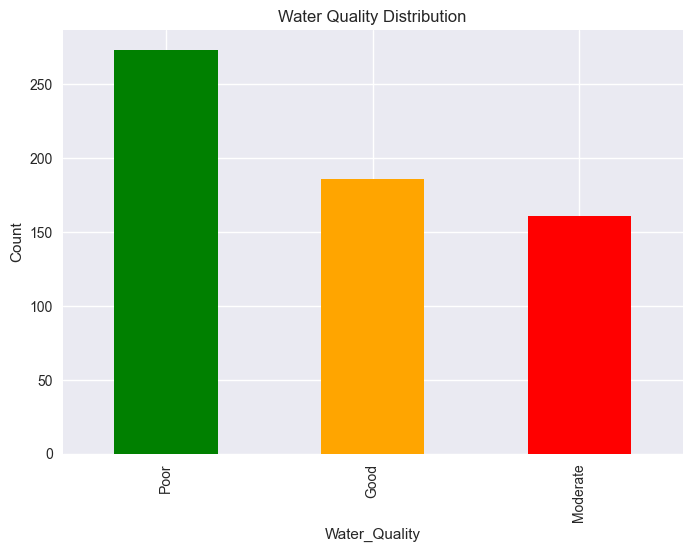

In [12]:
# How many Good, Moderate, Poor water bodies?
df['Water_Quality'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Water Quality Distribution')
plt.ylabel('Count')
plt.show()

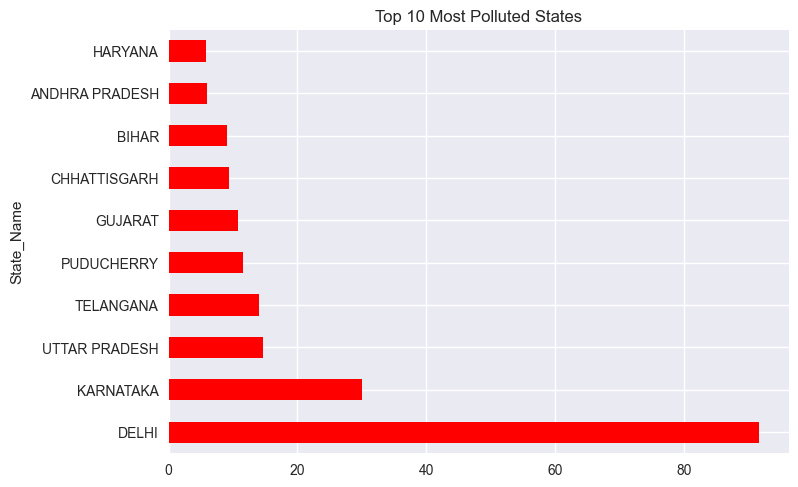

In [28]:
#Top 10 Polluted States
# Which states have highest BOD (pollution)?
df.groupby('State_Name')['BOD_Max'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='red')
plt.title('Top 10 Most Polluted States')
plt.show()

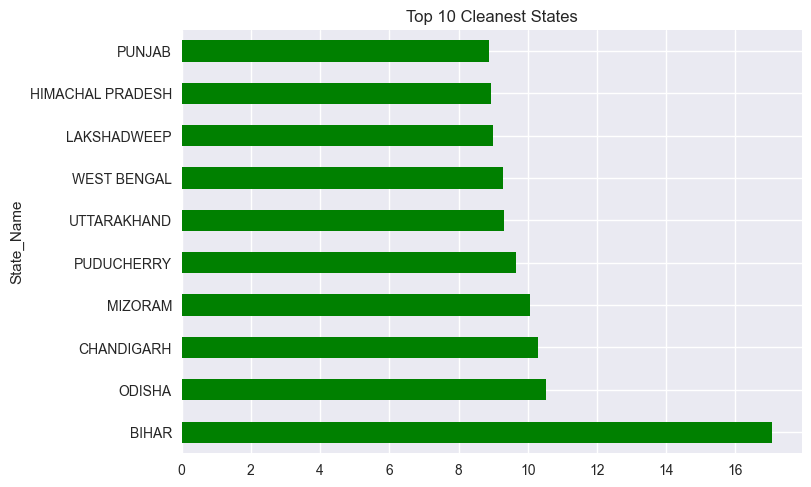

In [29]:
#Top 10 Cleanest States
df.groupby('State_Name')['DO_Max'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title('Top 10 Cleanest States')
plt.show()

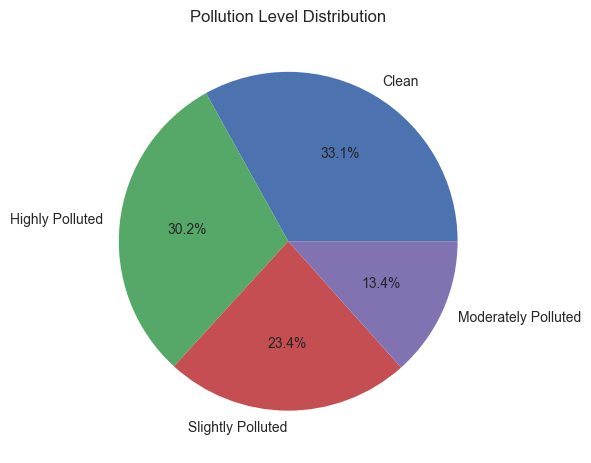

In [30]:
#Pollution Level Pie Chart
df['Pollution_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Pollution Level Distribution')
plt.show()

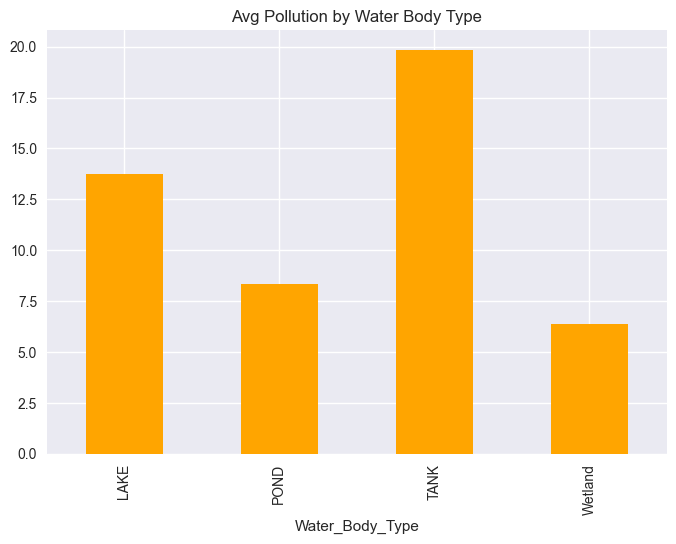

In [31]:
#Water Body Type vs Pollution
df.groupby('Water_Body_Type')['BOD_Max'].mean().plot(kind='bar', color='orange')
plt.title('Avg Pollution by Water Body Type')
plt.show()

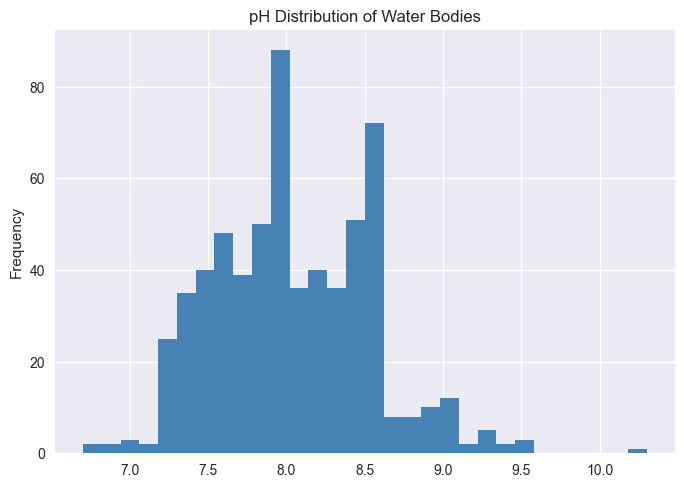

In [13]:
#pH Distribution
df['pH_Max'].plot(kind='hist', bins=30, color='steelblue')
plt.title('pH Distribution of Water Bodies')
plt.show()